In [19]:
import numpy as np
import matplotlib.pyplot as plt

## PART 2, a

In [20]:
phi_r = 365 #N/m
phi_ti = 245 #N/m
phi_to = 98 #N/m

a = 2.46e-10 #m
d = a/np.sqrt(3) #m
M = 12 * 1.66054e-27 #kg

$
\delta_n, \alpha
$:

In [21]:
delta = np.array([
    [ d,    0,            0],
    [-d/2, -d*np.sqrt(3)/2, 0], 
    [-d/2,  d*np.sqrt(3)/2, 0], 
])
angles = [0,
          2*np.pi/3,
          4*np.pi/3]

$ K_{AB}$ :

In [22]:
K_AB1 = np.array([[phi_r, 0, 0], 
                 [0, phi_ti, 0], 
                 [0, 0, phi_to]])


In [23]:
def rotation_matrix(theta):
    return np.array([[np.cos(theta), -np.sin(theta), 0],
                     [np.sin(theta),  np.cos(theta), 0],
                     [0,              0,             1]])

$K_{AB_{ROT}} = R K_{AB} R^T$

In [24]:
R = rotation_matrix(angles[1])
K_AB_rot = [rotation_matrix(t) @ K_AB1 @ rotation_matrix(t).T for t in angles]
K_AB_rot 

[array([[365.,   0.,   0.],
        [  0., 245.,   0.],
        [  0.,   0.,  98.]]),
 array([[275.        , -51.96152423,   0.        ],
        [-51.96152423, 335.        ,   0.        ],
        [  0.        ,   0.        ,  98.        ]]),
 array([[275.        ,  51.96152423,   0.        ],
        [ 51.96152423, 335.        ,   0.        ],
        [  0.        ,   0.        ,  98.        ]])]

Dynamical matrix

$$
D(q)\vec{u} = M*\omega^2 \vec{u}
$$

$$D(\mathbf{q}) = \frac{1}{M}\begin{pmatrix} D_{AA} & D_{AB} \\ D_{BA} & D_{BB} \end{pmatrix}$$

$$D_{AA} = D_{BB} = \sum_n K_{AB_{ROT}}^{(n)}, \qquad D_{AB} = -\sum_n K_{AB_{ROT}}^{(n)} e^{i\mathbf{q}\cdot\boldsymbol{\delta}_n}$$

In [25]:
def dynamical_matrix(q):
    D_AA = sum(K_AB_rot)                         # on-site block (real)
    D_AB = np.zeros((3, 3), dtype=complex)    # off-diagonal block
    for n in range(3):
        phase = np.exp(1j * np.dot(q, delta[n]))
        D_AB -= K_AB_rot[n] * phase
    D_BB = D_AA.copy()
    D_BA = D_AB.conj().T
    return np.block([[D_AA, D_AB],
                     [D_BA, D_BB]]) / M


$\Gamma = \begin{pmatrix} 0 \\ 0 \\ 0\end{pmatrix}$; $K = \dfrac{4\pi}{3 a} \begin{pmatrix} 0 \\ 1 \\ 0\end{pmatrix}$

In [26]:
Gamma = np.array([0,0,0])
K = 4*np.pi/3/a*np.array([0,1,0])

In [27]:
n_q = 101
t_vals = np.linspace(0, 1, n_q)
q_path = np.outer(t_vals, K) 

In [28]:
freqs_along_path = []
for q in q_path:
    D = dynamical_matrix(q)
    freqs = np.sqrt(np.linalg.eigvals(D))
    freqs_along_path.append(np.sort(freqs.real))
freqs_along_path = np.array(freqs_along_path)

    

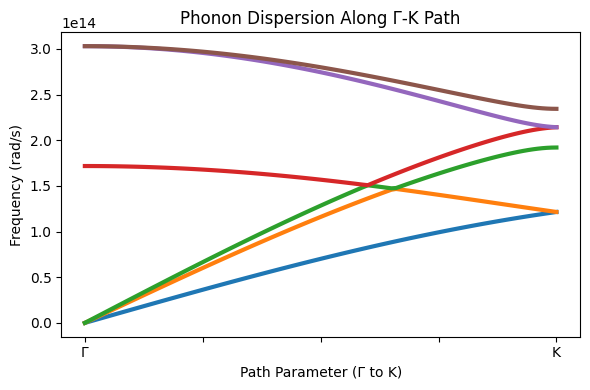

In [38]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_vals, freqs_along_path, linestyle='-', linewidth=3)
ax.set_xlabel('Path Parameter (Γ to K)')
ax.set_ylabel('Frequency (rad/s)')
ax.set_title('Phonon Dispersion Along Γ-K Path')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_xticklabels(['Γ', '', '', '', 'K'])
plt.tight_layout()
plt.show()
fig.tight_layout()
fig.savefig('dispersion_relation_Gr.png', dpi=300)

## PART 2, b


In [30]:
import pandas as pd

In [31]:
k_B = 1.38065e-23 # J/K
hbar = 1.05457e-34 # J*s
e = 1.60218e-19 # C

m_c = 12 * 1.66054e-27 # kg

In [32]:
dos_df = pd.read_csv('graphene.csv')
dos_df['omega'] = dos_df['Energy (meV)'] * 1e-3 * e / hbar # convert meV to rad/s
Int = np.trapz(dos_df['DOS (a.u.)'], dos_df['omega'])
dos_df['Normalized DOS'] = dos_df['DOS (a.u.)'] / Int*6
dos_df.head()

/var/folders/5h/80_mph8s1tg289gn7wkq8qq00000gn/T/ipykernel_51819/3722152225.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Int = np.trapz(dos_df['DOS (a.u.)'], dos_df['omega'])


,DOS (a.u.),Energy (meV),omega,Normalized DOS
0,0.022300,0.000000,0.000000e+00,7.391838e-15
1,0.023000,3.000000,4.557820e+12,7.623869e-15
2,0.025000,9.374996,1.424318e+13,8.286814e-15
3,0.027388,15.783765,2.397985e+13,9.078351e-15
4,0.029791,24.128391,3.665762e+13,9.874840e-15


In [33]:
def Bose_Einstein(omega, T):
    x = np.clip(hbar * omega / (k_B * T), 0, 500)
    # avoid 1/(exp(0)-1) = inf at omega=0
    with np.errstate(divide='ignore', invalid='ignore'):
        result = np.where(omega == 0, 0.0, 1 / (np.exp(x) - 1))
    return result

In [34]:
def Total_Energy(T):
    omega = dos_df['omega'].values
    dos = dos_df['Normalized DOS'].values
    n_omega = Bose_Einstein(omega, T)
    energy = hbar * omega * (n_omega + 0.5) * dos
    return np.trapz(energy, omega)
def heat_capacity(T):
    dT = 1e-6
    return 1/(2*m_c) * (Total_Energy(T + dT) - Total_Energy(T)) / dT

In [35]:
T_range = np.linspace(1, 1000, 1000)
C_range = [heat_capacity(T) for T in T_range]

/var/folders/5h/80_mph8s1tg289gn7wkq8qq00000gn/T/ipykernel_51819/1074162550.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(energy, omega)


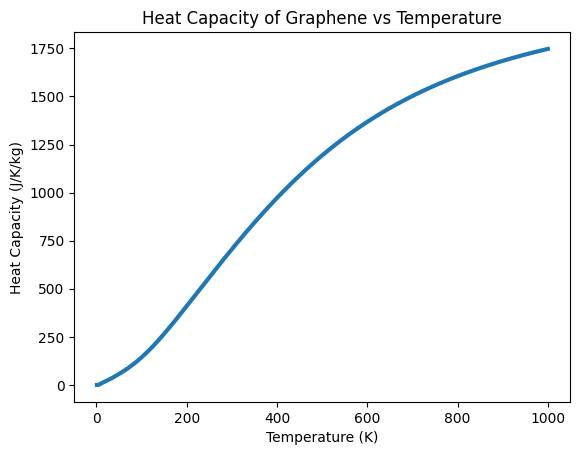

In [37]:
fig, ax = plt.subplots()
ax.plot(T_range, C_range, linestyle='-', linewidth=3)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Heat Capacity (J/K/kg)')
ax.set_title('Heat Capacity of Graphene vs Temperature')
plt.show()
fig.tight_layout()
fig.savefig('heat_capacity_vs_temperature_Gr.png', dpi=300)